In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Same data window as yesterday
spy = yf.download("SPY", start="2020-01-01", end="2024-12-31")
returns = spy["Close"].pct_change(fill_method=None).dropna()

# ── Historical VaR ─────────────────────────────────────────────
var_95_hist = np.percentile(returns, 5)
var_99_hist = np.percentile(returns, 1)

print("─── Historical VaR (real SPY daily returns) ───")
print(f"95% VaR (daily): {var_95_hist*100:.2f}%")
print(f"99% VaR (daily): {var_99_hist*100:.2f}%")
print(f"Meaning: on 95% of trading days SPY lost less than {var_95_hist*100:.2f}%")

# ── CVaR / Expected Shortfall ──────────────────────────────────
cvar_95 = float(returns[returns <= var_95_hist].mean())
cvar_99 = float(returns[returns <= var_99_hist].mean())

print("\n─── CVaR / Expected Shortfall ───")
print(f"95% CVaR (daily): {cvar_95*100:.2f}%")
print(f"99% CVaR (daily): {cvar_99*100:.2f}%")
print(f"Meaning: when losses exceed VaR, avg loss is {cvar_95*100:.2f}%")

# ── Annualised comparison ──────────────────────────────────────
ann_var = var_95_hist * np.sqrt(252)
print(f"\n─── Comparison to yesterday ───")
print(f"Simulated 1-year VaR (yesterday):  -19.00%")
print(f"Historical daily VaR annualised:    {ann_var*100:.2f}%")
print(f"Difference: {abs(-0.19 - ann_var)*100:.2f}% — model calibration check")


[*********************100%***********************]  1 of 1 completed

─── Historical VaR (real SPY daily returns) ───
95% VaR (daily): -1.93%
99% VaR (daily): -3.62%
Meaning: on 95% of trading days SPY lost less than -1.93%

─── CVaR / Expected Shortfall ───
95% CVaR (daily): -3.20%
99% CVaR (daily): -5.63%
Meaning: when losses exceed VaR, avg loss is -3.20%

─── Comparison to yesterday ───
Simulated 1-year VaR (yesterday):  -19.00%
Historical daily VaR annualised:    -30.58%
Difference: 11.58% — model calibration check



/tmp/ipykernel_528/2770559833.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cvar_95 = float(returns[returns <= var_95_hist].mean())
/tmp/ipykernel_528/2770559833.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cvar_99 = float(returns[returns <= var_99_hist].mean())


/tmp/ipykernel_528/3131980861.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(spy["Close"].iloc[-1])


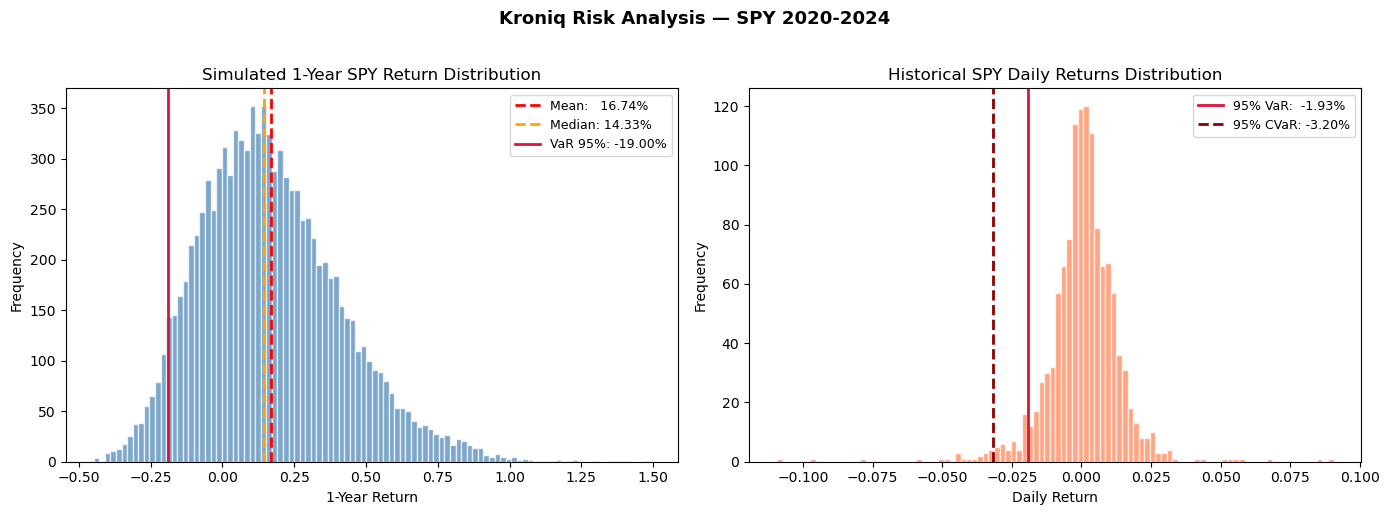


Mean (16.74%) > Median (14.33%)
Right skew confirmed — long right tail of high return outcomes pulls mean above median.


In [3]:
# ── Rebuild simulation from yesterday ─────────────────────────
last_price = float(spy["Close"].iloc[-1])
daily_vol  = returns.std()
daily_ret  = returns.mean()
np.random.seed(42)
sim_rets = np.random.normal(daily_ret, daily_vol, (252, 10000))
price_paths = last_price * np.cumprod(1 + sim_rets, axis=0)
final_prices = price_paths[-1, :]
sim_1yr = (final_prices - last_price) / last_price

# ── Two chart layout ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: simulated 1-year return distribution
axes[0].hist(sim_1yr, bins=100, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].axvline(sim_1yr.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean:   {sim_1yr.mean():.2%}")
axes[0].axvline(np.median(sim_1yr), color="orange", linestyle="--", linewidth=2,
                label=f"Median: {np.median(sim_1yr):.2%}")
axes[0].axvline(np.percentile(sim_1yr, 5), color="crimson", linewidth=2,
                label=f"VaR 95%: {np.percentile(sim_1yr,5):.2%}")
axes[0].set_title("Simulated 1-Year SPY Return Distribution")
axes[0].set_xlabel("1-Year Return")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

# RIGHT: historical daily returns distribution
ret_vals = returns.squeeze().values
axes[1].hist(ret_vals, bins=100, color="coral", alpha=0.7, edgecolor="white")
axes[1].axvline(var_95_hist, color="crimson", linewidth=2,
                label=f"95% VaR:  {var_95_hist*100:.2f}%")
axes[1].axvline(cvar_95, color="darkred", linestyle="--", linewidth=2,
                label=f"95% CVaR: {cvar_95*100:.2f}%")
axes[1].set_title("Historical SPY Daily Returns Distribution")
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=9)

plt.suptitle("Kroniq Risk Analysis — SPY 2020-2024", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("kroniq_return_distributions.png", dpi=150)
plt.show()

print(f"\nMean ({sim_1yr.mean():.2%}) > Median ({np.median(sim_1yr):.2%})")
print("Right skew confirmed — long right tail of high return outcomes pulls mean above median.")